In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Exploratory Data Analysis(EDA)

## Understanding data characteristics and finding hidden patterns.

### The main objectives of Exploratory Data Analysis (EDA) are:
### Detecting errors and missing values: Ensuring data quality and addressing any deficiencies.
### Identifying patterns and relationships: Understanding how variables influence each other.
### Verifying hypotheses: Ensuring that the data supports the project's assumed directions.
### Detecting outliers: Identifying data that deviates significantly from the norm and may affect the accuracy of the results.

#### Software library recovery

In [73]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

#### Path Configuration

In [74]:
base_path = '/content/drive/MyDrive/archive (31)'
data_root_dir = os.path.join(base_path, 'images', 'images')

#### Checking Class Imbalance

##### Visualization
###### To draw a bar chart showing the number of images for each category
###### The goal is not just to draw, but to ensure data balance.

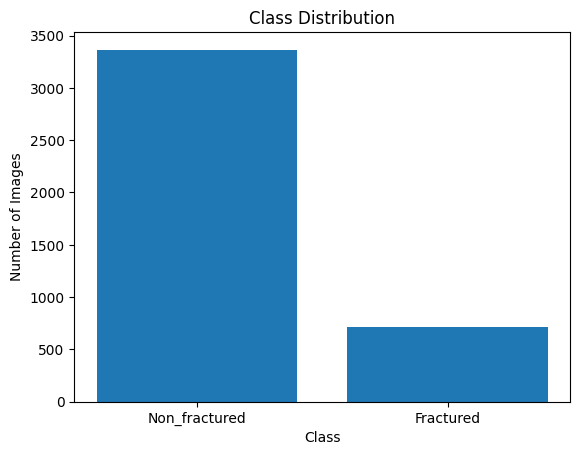

In [75]:
import os
import matplotlib.pyplot as plt

class_counts = {}

for class_name in os.listdir(data_root_dir):
    class_path = os.path.join(data_root_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

##### (Data Visualization/Inspection).
##### "The quality and appearance of the images" (quality).

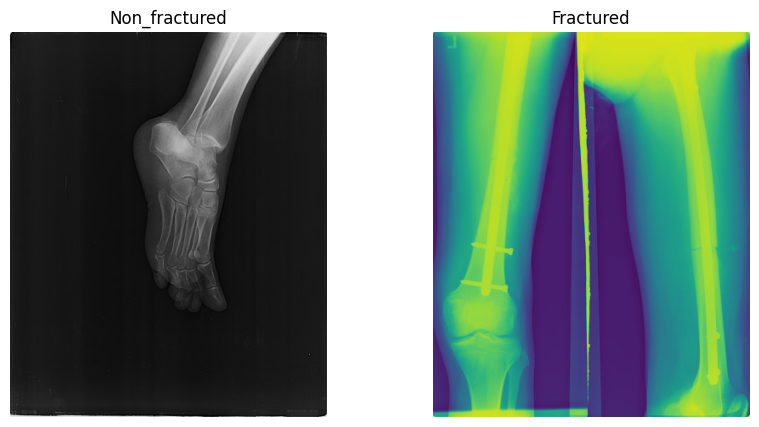

In [76]:
import random
from PIL import Image

plt.figure(figsize=(10,5))

for i, class_name in enumerate(os.listdir(data_root_dir)):
    class_path = os.path.join(data_root_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

##### Image Dimension Analysis
##### Examine the first 100 images from each category ([:100]).
##### It extracts the width and height of each of its images.

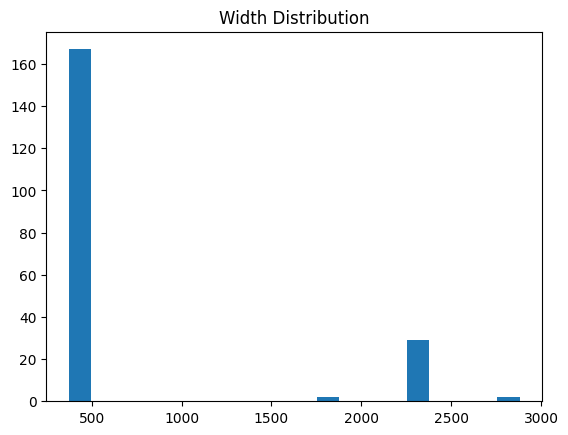

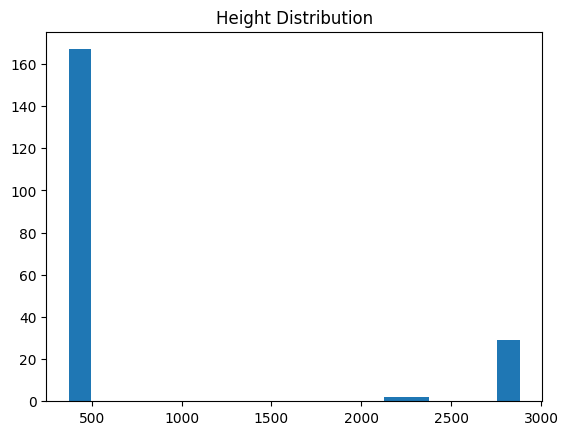

In [77]:
widths = []
heights = []

for class_name in os.listdir(data_root_dir):
    class_path = os.path.join(data_root_dir, class_name)

    for img_name in os.listdir(class_path)[:100]:  # sample
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            continue

plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.show()

plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.show()

##### "Final data package verification" (Batch Inspection).

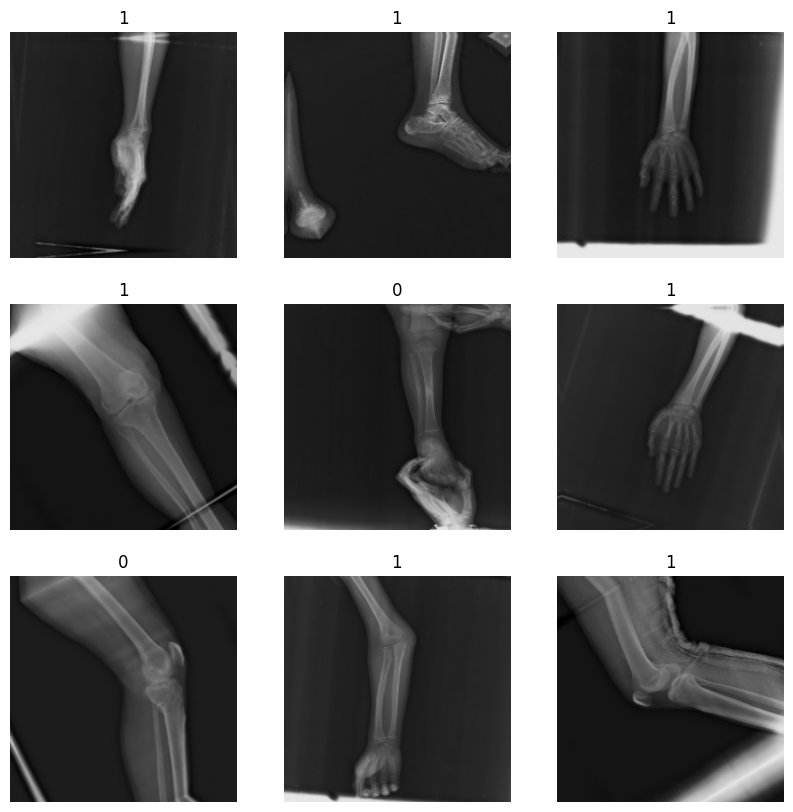

In [78]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(labels[i].numpy())
        plt.axis("off")
    plt.show()

### "Data Loading & Splitting".

In [79]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_root_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_root_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 4083 files belonging to 2 classes.
Using 3267 files for training.
Found 4083 files belonging to 2 classes.
Using 816 files for validation.


### "Specific Image Inspection"

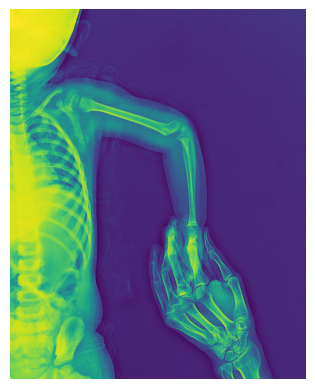

In [80]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = '/content/drive/MyDrive/archive (31)'
img_path = os.path.join(base_path, 'images', 'images', 'Fractured', 'IMG0000059.jpg') # Corrected path to an existing image
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

### "Accurate class counting".

In [81]:
import os

base_path = '/content/drive/MyDrive/archive (31)'

fractured_path = os.path.join(base_path, 'images', 'images', 'Fractured')
normal_path = os.path.join(base_path, 'images', 'images', 'Non_fractured')

fractured = len(os.listdir(fractured_path))
normal = len(os.listdir(normal_path))

print("Fractured:", fractured)
print("Normal:", normal)

Fractured: 717
Normal: 3366


### "Improving data flow performance" (Pipeline Performance Optimization).
### It relates to the speed of training and the efficiency of using device resources (RAM and GPU).

In [82]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### "Artificial data augmentation".

In [83]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def augment(images, labels):
    return data_augmentation(images), labels

train_ds = train_ds.map(augment)

### "Building the Model Architecture"
### Using a professional technique called "transfer learning".

In [86]:
x = base_model.output

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_14        │ (None, 224, 224,  │          0 │ input_layer_9[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_7     │ (None, 224, 224,  │          7 │ rescaling_14[0][… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_15        │ (None, 224, 224,  │          0 │ normalization_7[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_15[0][… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

### "Model Training Phase" begins.

In [88]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
     62/Unknown 55s 540ms/step - accuracy: 0.6295 - loss: 0.7999

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 ━━━━━━━━━━━━━━━━━━━━ 72s 809ms/step - accuracy: 0.6496 - loss: 0.7406 - val_accuracy: 0.8519 - val_loss: 0.4325
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 358ms/step - accuracy: 0.7488 - loss: 0.5650 - val_accuracy: 0.8565 - val_loss: 0.3829
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - accuracy: 0.7785 - loss: 0.5313 - val_accuracy: 0.8681 - val_loss: 0.3497
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 380ms/step - accuracy: 0.7923 - loss: 0.4880 - val_accuracy: 0.8681 - val_loss: 0.3306
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 356ms/step - accuracy: 0.8092 - loss: 0.4451 - val_accuracy: 0.8727 - val_loss: 0.3227
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 372ms/step - accuracy: 0.8220 - loss: 0.4425 - val_accuracy: 0.8657 - val_loss: 0.3129
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 389ms/step - accuracy: 0.8205 - loss: 0.4323 - val_accuracy: 0.8773 - val_loss: 0.3052
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 349ms/step - accuracy: 0.8292 - loss: 0.4126 - val_accuracy: 0.877

### Fine-Tuning

In [89]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 75s 763ms/step - accuracy: 0.7923 - loss: 0.4517 - val_accuracy: 0.8819 - val_loss: 0.3062
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 374ms/step - accuracy: 0.8056 - loss: 0.4449 - val_accuracy: 0.8796 - val_loss: 0.3158
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 367ms/step - accuracy: 0.8026 - loss: 0.4530 - val_accuracy: 0.8727 - val_loss: 0.3232
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 362ms/step - accuracy: 0.8061 - loss: 0.4335 - val_accuracy: 0.8681 - val_loss: 0.3273
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 374ms/step - accuracy: 0.8123 - loss: 0.4429 - val_accuracy: 0.8681 - val_loss: 0.3304


### "Final Model Evaluation".

In [90]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
              precision    recall  f1-score   support

           0       0.67      0.30      0.41        67
           1       0.88      0.97      0.93       365

    accuracy                           0.87       432
   macro avg       0.77      0.64      0.67       432
weighted avg       0.85      0.87      0.85       432



### "Learning Curves Analysis".

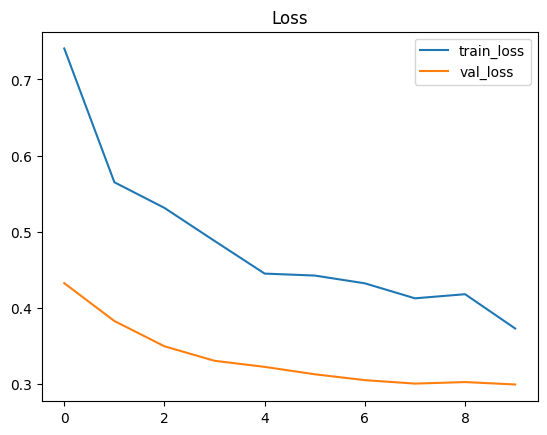

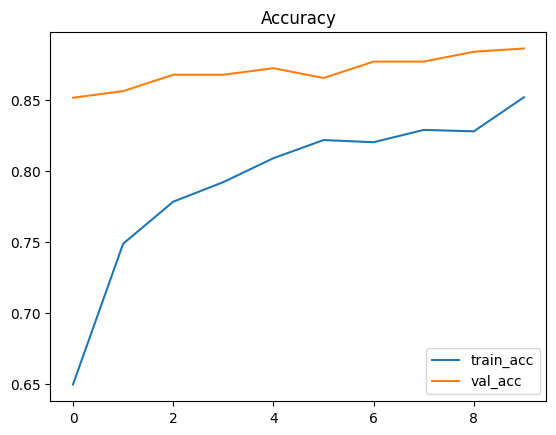

In [91]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

### "Confusion Matrix"
#### The matrix divides the results into four main quadrants:
#### True Positives (TP): The number of cases that were "fractured" and predicted by the model (Excellent).
#### True Negatives (TN): The number of cases that were "healthy" and predicted by the model (Excellent).
#### False Positives (FP): The number of cases that were "healthy" but the model incorrectly identified them as "fractured."
#### False Negatives (FN): (Medically the most serious) The number of cases that were actually "fractured" but the 
#### model incorrectly identified them as "healthy."

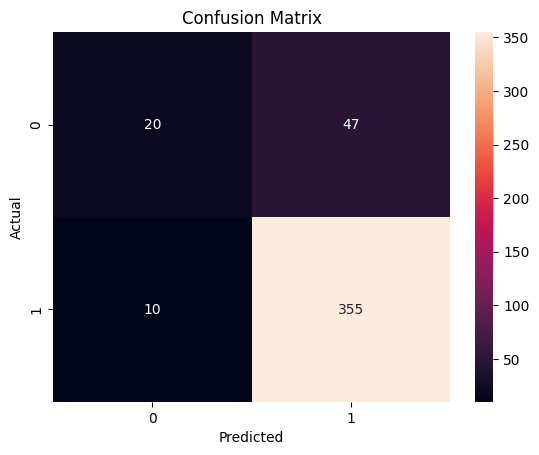

In [92]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### "Metrics Visualization" (Metrics Comparison Analysis).

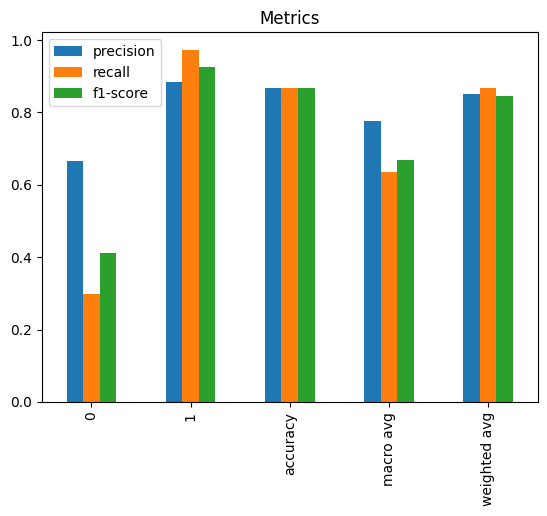

In [93]:
report = classification_report(y_true, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

df[['precision','recall','f1-score']].plot(kind='bar')
plt.title("Metrics")
plt.show()

### "Model Saving and Exporting".

In [ ]:
model.save("fracture_model_tf.h5")

### "Prediction Function" (Inference Function)

In [94]:
import cv2

def predict(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]
    return "Fractured" if pred > 0.5 else "Normal"